<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<center>
    <b>
        <h3>Machine Learning and Deep Learning Fundamentals and Applications - 2501CS633</h3>
        <h3>Lab - 10</h3>
        <h3>Rathod Harmik Kamleshbhai - 24010101680</h3>
    </b>
</center>

# Step 1: Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids


# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [2]:
data = pd.read_csv('StudentsPerformance.csv')

In [3]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [4]:
print(data.info())
print(data.describe())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000

# Step 4: Display PairPlot

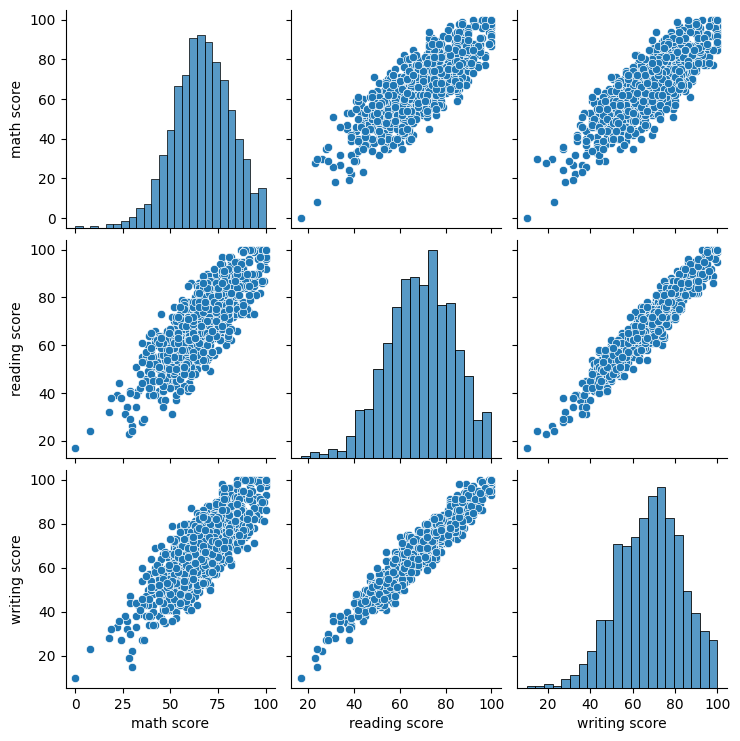

In [5]:
sns.pairplot(data)
plt.show()

# Step 5: Correlation heatmap

C:\Users\Gaurav\AppData\Local\Temp\ipykernel_3672\104075714.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(), annot=True)


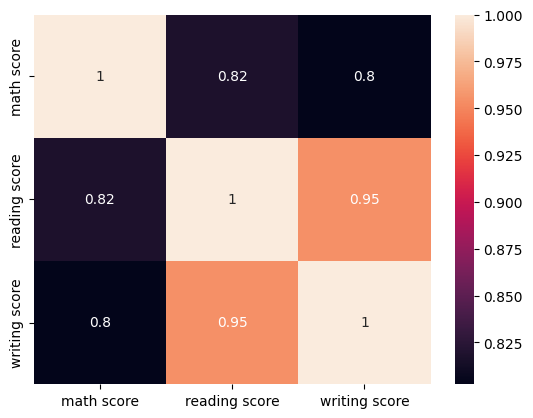

In [9]:
sns.heatmap(data.corr(), annot=True)
plt.show()

# Step 6: Distribution of numerical features

In [ ]:
X_scale = ['math score', 'reading score', 'writing score']
data[X_scale].hist(bins=30, figsize=(12,3))
plt.show()

# Step 7: Apply StandardScaler

In [20]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data[X_scale])
x_scaled

array([[ 0.39002351,  0.19399858,  0.39149181],
       [ 0.19207553,  1.42747598,  1.31326868],
       [ 1.57771141,  1.77010859,  1.64247471],
       ...,
       [-0.46775108,  0.12547206, -0.20107904],
       [ 0.12609287,  0.60515772,  0.58901542],
       [ 0.71993682,  1.15336989,  1.18158627]])

# Step 8: Elbow method to find optimal k

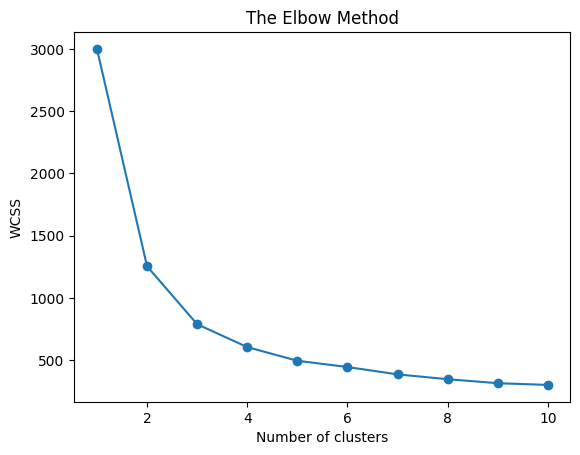

In [17]:
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)    

plt.plot(range(1,11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [57]:
k=3
kmeans = KMeans(n_clusters=k, init='k-means++')
y_kmeans = kmeans.fit_predict(x_scaled)

data['Cluster_KMeans'] = y_kmeans
data[data['Cluster_KMeans'] == 2]['test preparation course'].value_counts()

none         283
completed    161
Name: test preparation course, dtype: int64

# Step 10: Print Cluster Center

In [23]:

print("Cluster Centers(scaled):")
print(kmeans.cluster_centers_)

print("\nCluster Centers(original):")
print(scaler.inverse_transform(kmeans.cluster_centers_))


Cluster Centers(scaled):
[[-0.04951336 -0.04870596 -0.01529686]
 [-1.18720058 -1.26762535 -1.28838441]
 [ 1.03099793  1.09485536  1.06358515]]

Cluster Centers(original):
[[65.33860045 68.45823928 67.82167043]
 [48.09638554 50.67068273 48.48594378]
 [81.71428571 85.1461039  84.20779221]]


# Step 11: Plot Cluster

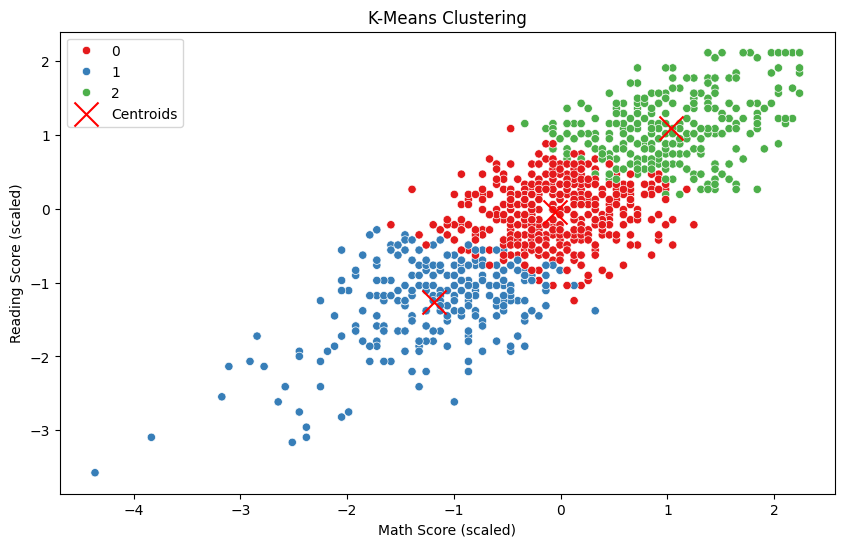

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=y_kmeans, palette='Set1')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, c='red', marker="x", label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Math Score (scaled)')
plt.ylabel('Reading Score (scaled)')
plt.legend()
plt.show()

# Step 12:Analyze clusters 

In [ ]:
for cluster in range(k):
    print(f"Cluster {cluster}:")
    print(data[data['Cluster_KMeans'] == cluster][X_scale].describe())

In [ ]:
print(pd.crosstab(data['Cluster_KMeans'], data['gender']))
print(pd.crosstab(data['Cluster_KMeans'], data['parental level of education']))

# Step 13: Perform K-Medoids

In [42]:
kmedoids = KMedoids(n_clusters=k, random_state=42)
y_kmedoids = kmedoids.fit_predict(x_scaled)
data['Cluster_KMedoids'] = y_kmedoids

In [43]:

print("Cluster Centers(scaled):")
print(kmedoids.cluster_centers_)

print("\nCluster Centers(original):")
print(scaler.inverse_transform(kmedoids.cluster_centers_))


Cluster Centers(scaled):
[[-0.00587246  0.19399858  0.12812699]
 [-0.99561237 -0.90242577 -0.99117351]
 [ 0.9178848   1.08484337  1.11574507]]

Cluster Centers(original):
[[66. 72. 70.]
 [51. 56. 53.]
 [80. 85. 85.]]


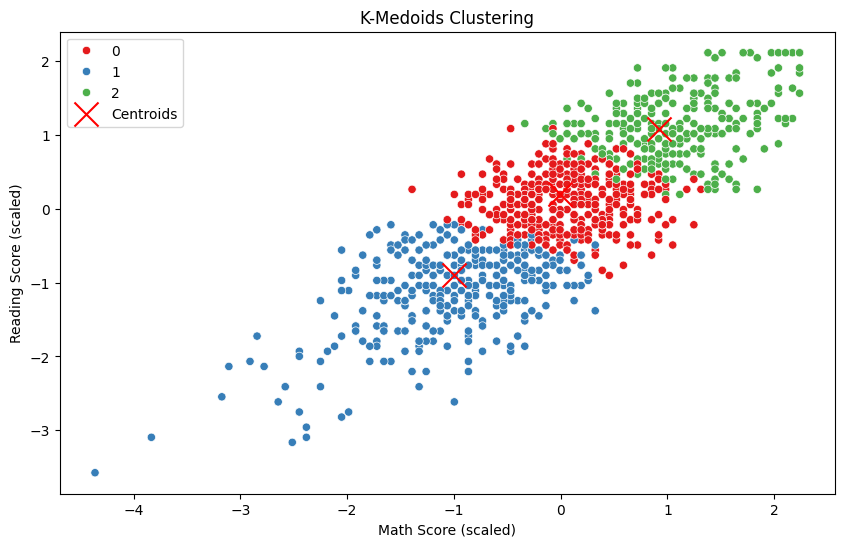

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=y_kmedoids, palette='Set1')
plt.scatter(kmedoids.cluster_centers_[:,0], kmedoids.cluster_centers_[:,1], s=300, c='red', marker="x", label='Centroids')
plt.title('K-Medoids Clustering')
plt.xlabel('Math Score (scaled)')
plt.ylabel('Reading Score (scaled)')
plt.legend()
plt.show()

# Step:14 Comparison of K-means and K-medoids Clusters

In [ ]:
from sklearn.metrics import silhouette_score

print("KMeans Silhouette Score:", silhouette_score(x_scaled, y_kmeans))
print("KMedoids Silhouette Score:", silhouette_score(x_scaled, y_kmedoids))

# Step: 15 | USE KMEAN++


In [ ]:
kmeans_random = KMeans(n_clusters=k, init='random', random_state=42)
y_kmeans_random = kmeans_random.fit_predict(x_scaled)

kmeans_plus = KMeans(n_clusters=k, init='k-means++', random_state=42)
y_kmeans_plus = kmeans_plus.fit_predict(x_scaled)

print("Random Init - Inertia:", kmeans_random.inertia_)
print("KMeans++ Init - Inertia:", kmeans_plus.inertia_)